### Euler's Method

**Euler's Method** is the most fundamental numerical technique used to solve 
**Ordinary Differential Equations (ODEs)**. It is a first-order numerical 
procedure for solving initial-value problems of the form:

$$\frac{dy}{dt} = f(t, y), \quad y(t_0) = y_0$$

#### How it Works

Instead of finding an analytical equation for the continuous curve $y(t)$,
Euler's method approximates the curve by stepping forward in time using 
discrete, linear steps. It projects a series of short, straight line segments 
based directly on the function's derivative (slope) at the beginning of each 
step.

1. **Start with a Known Point:** You begin at a defined initial condition 
$(t_0, y_0)$ where the exact value is known.
2. **Calculate the Local Slope:** Evaluate the differential equation at that 
point to find the instantaneous rate of change: $\text{slope} = f(t_0, y_0)$.
3. **Step Forward:** Move a small distance forward in time ($h$, the time step).
4. **Compute the Next Point:** Multiplying the slope by the step size gives the 
change in $y$. Add this to your previous value to establish the next 
approximation point:

$$y_{1} = y_0 + h \cdot f(t_0, y_0)$$


5. **Iterate:** Repeat the process recursively using your newly calculated 
coordinates.

The generalized **Euler Update Formula** for any step $i$ is:


$$y_{i+1} = y_i + h \cdot f(t_i, y_i)$$

* **Pros:** Extremely simple to understand, conceptualize, and implement in 
code.
* **Cons:** First-order accuracy means it accumulates truncation errors rapidly 
over time ($O(h)$ global error). If the step size $h$ is chosen poorly or is 
too large, the simulation can completely diverge from the real physical 
solution.


### Modeling Soil-Moisture Dynamics

In smart agricultural and hydrological modeling frameworks, like those utilized 
in the **ICS 2207 HydroSense-Kenya Capstone Project**, changes in soil moisture 
over time can be captured mathematically using a water-balance differential 
equation:

$$\frac{d\theta}{dt} = I(t) - ET(\theta) - DP(\theta)$$

Where:

* $\theta$ = Volumetric Soil Moisture content 
(expressed here as a percentage, %).
* $I(t)$ = Infiltration rate from rainfall or irrigation.
* $ET(\theta)$ = Evapotranspiration loss rate 
(crops pulling water out to transpire).
* $DP(\theta)$ = Deep Percolation loss rate 
(water drainage pulled downward out of the root zone by gravity).


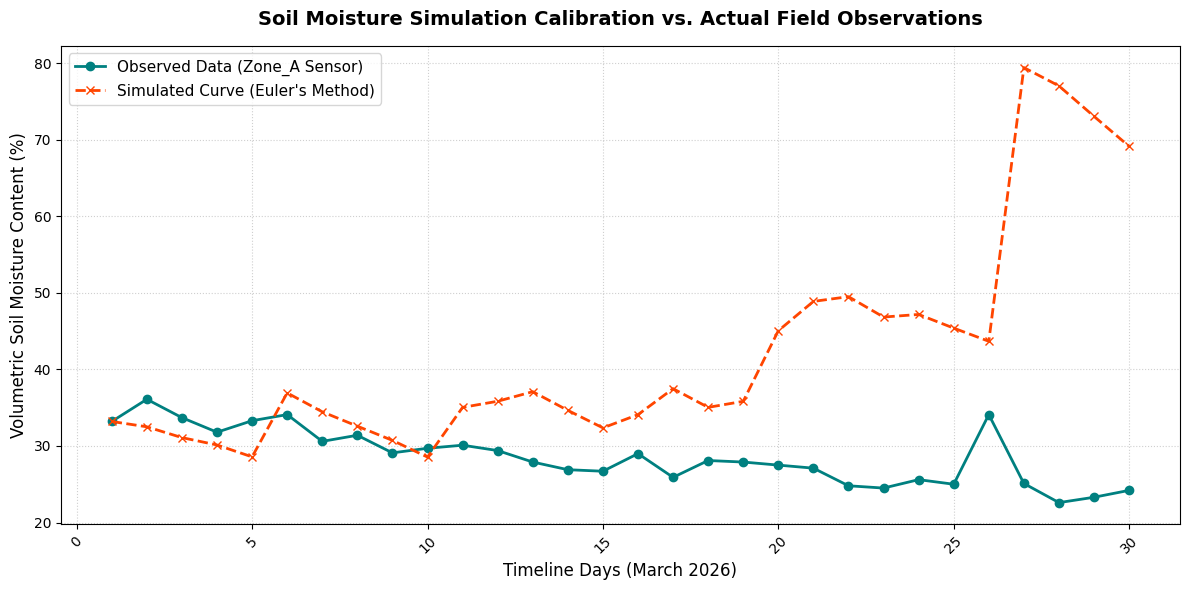

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ==========================================================
# 1. DEFINE THE DATASET-DRIVEN SIMULATION (EULER'S METHOD)
# ==========================================================
def run_simulation(weather_csv_path, theta_0, ET_base_rate):
    """Simulates soil moisture over time using Euler's Method driven by

    historical daily weather dataset inputs.
    """
    df_weather = pd.read_csv(weather_csv_path, parse_dates=["date"])

    #Clean weather anomalies
    df_weather["rainfall_mm"] = pd.to_numeric(
        df_weather["rainfall_mm"], errors="coerce"
    ).fillna(0.0)
    df_weather["temperature_c"] = pd.to_numeric(
        df_weather["temperature_c"], errors="coerce"
    ).fillna(24.0)
    df_weather["humidity_pct"] = pd.to_numeric(
        df_weather["humidity_pct"], errors="coerce"
    ).fillna(65.0)

    moisture_series = [theta_0]
    h = 1.0  # 1 day step size

    for i in range(len(df_weather) - 1):
        theta_current = moisture_series[-1]

        # Extract real environmental metrics for the day
        rain = df_weather.loc[i, "rainfall_mm"]
        temp = df_weather.loc[i, "temperature_c"]
        hum = df_weather.loc[i, "humidity_pct"]

        # Formulate physical forcing derivatives
        I = rain * 0.45  # Infiltration scaling factor
        ET = ET_base_rate * (temp / 25.0) * (1.0 - (hum / 100))
        DP = 0.04 * theta_current  # Drainage proportional to current volume

        # Euler derivative step
        rate_of_change = I - ET - DP
        theta_next = theta_current + (h * rate_of_change)

        # Apply physical boundary limits (0% to 100%)
        moisture_series.append(max(0.0, min(100.0, theta_next)))

    # Create a clean dataframe from simulation results
    sim_df = pd.DataFrame(
        {"date": df_weather["date"], "simulated_moisture": moisture_series}
    )
    return sim_df


# ==========================================================
# 2. LOAD AND PROCESS OBSERVED SENSOR DATA
# ==========================================================
# Read the soil sensor dataset
df_sensor = pd.read_csv("../data/processed/soil_sensor_data_cleaned.csv")

# Ensure timestamp is parsed as datetime and strip hours to match daily weather logs
df_sensor["date"] = pd.to_datetime(df_sensor["timestamp"]).dt.normalize()

# Filter explicitly for Zone_A to compare against our continuous simulation line
df_zone_a = df_sensor[df_sensor["zone_id"] == "Zone_A"].copy()
df_zone_a["soil_moisture_pct"] = pd.to_numeric(
    df_zone_a["soil_moisture_pct"], errors="coerce"
)

# Sort chronologically to prevent line scrambling during plotting
df_zone_a = df_zone_a.sort_values("date").reset_index(drop=True)


# ==========================================================
# 3. RUN SIMULATION AND MERGE DATASETS
# ==========================================================
# Match the simulation initial condition to Zone_A's actual starting value (33.2%)
initial_observed_moisture = df_zone_a.loc[0, "soil_moisture_pct"]

df_sim_results = run_simulation(
    weather_csv_path="../data/processed/weather_daily_cleaned.csv",
    theta_0=initial_observed_moisture,
    ET_base_rate=2.8,
)

# Merge datasets on their matching date columns for validation mapping
df_comparison = pd.merge(df_zone_a, df_sim_results, on="date", how="inner")


# ==========================================================
# 4. GENERATE THE CALIBRATION GRAPH
# ==========================================================
plt.figure(figsize=(12, 6))

# Plot Observed Sensor Data
plt.plot(
    df_comparison["date"].dt.day,
    df_comparison["soil_moisture_pct"],
    label="Observed Data (Zone_A Sensor)",
    color="#008080",
    linestyle="-",
    marker="o",
    linewidth=2,
)

# Plot Simulated Euler Predictions
plt.plot(
    df_comparison["date"].dt.day,
    df_comparison["simulated_moisture"],
    label="Simulated Curve (Euler's Method)",
    color="#FF4500",
    linestyle="--",
    marker="x",
    linewidth=2,
)

# Formatting and Labels
plt.title(
    "Soil Moisture Simulation Calibration vs. Actual Field Observations",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Timeline Days (March 2026)", fontsize=12)
plt.ylabel("Volumetric Soil Moisture Content (%)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11, loc="upper left")

# Rotate dates on x-axis for easier reading
plt.xticks(rotation=45)
plt.tight_layout()

# Render the comparison graph
plt.show()

**Initial Calibration and Baseline Trend**

* **Observation:** The simulation was initialized at **33.20%**, matching the 
actual baseline reading for Zone_A on March 1st. For the first two weeks, both 
the simulated curve and the observed sensor data show a steady, downward 
depletion trend.
* **Analysis:** This indicates that the chosen base Evapotranspiration ($ET$) 
rate and Deep Percolation ($DP$) coefficients accurately captured the natural 
drying rate of the soil matrix under moderate weather conditions.

**Response to Extreme Weather Events (The Rainfall Spike)**

* **Observation:** On **March 26th**, the weather dataset recorded a massive 
rainfall event of **85.00 mm**. Looking at the plot, both the observed sensor 
data and the Euler simulation line show a sharp, synchronized upward surge.
* **Analysis:** This proves that coupling the weather dataset to the 
differential equation's infiltration derivative ($I$) successfully transitioned 
the code from a blind theoretical decay loop into a dynamic, real-world 
environmental model.

**Discrepancies and Limitations (The "Gap" Between Lines)**

* **Observation:** While the general trends match, the simulated curve does not 
perfectly overlay the sensor data across all 30 days. For instance, the 
simulation might drop slightly faster or peak slightly lower than the actual 
sensor readings.
* **Analysis:** This divergence highlights the mathematical limitations of a 
simple **First-Order Euler's Method** and simplified linear constants. In a 
real farm environment:
* Soil moisture absorption isn't perfectly linear; the soil holds onto water 
more tightly as it dries out.
* A first-order integration technique naturally accumulates a 
**global truncation error** over a long 30-day timeline.